# Importaciones de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Configuración de estilos

In [2]:
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Carga de archivos

In [3]:
df_ml = pd.read_csv("../../data/hospital_deterioration_ml_ready.csv")
df_patients = pd.read_csv("../../data/patients.csv")

In [4]:
df_ml.head()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,nurse_alert,wbc_count,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,0,5.68,1.28,1.27,10.66,13.55,0.2621,24,M,2,Elective,0
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,0,5.46,1.18,1.22,11.94,13.65,0.3353,24,M,2,Elective,0
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,0,5.55,1.21,1.25,10.24,13.69,0.1678,24,M,2,Elective,0
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,0,5.50,1.13,1.24,10.72,13.61,0.1961,24,M,2,Elective,0
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,0,5.96,1.20,1.21,11.46,13.49,0.3000,24,M,2,Elective,0


In [5]:
df_patients.head()

,patient_id,age,gender,comorbidity_index,admission_type,baseline_risk_score,los_hours,deterioration_event,deterioration_within_12h_from_admission,deterioration_hour
0,1,24,M,2,Elective,0.2173,17,0,0,-1
1,2,74,F,3,Transfer,0.5558,33,1,0,16
2,3,65,F,7,ED,0.6325,55,0,0,-1
3,4,50,M,0,ED,0.2896,37,0,0,-1
4,5,49,M,0,ED,0.2507,22,0,0,-1


In [6]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 417866 entries, 0 to 417865
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   hour_from_admission     417866 non-null  int64  
 1   heart_rate              417866 non-null  float64
 2   respiratory_rate        417866 non-null  float64
 3   spo2_pct                417866 non-null  float64
 4   temperature_c           417866 non-null  float64
 5   systolic_bp             417866 non-null  float64
 6   diastolic_bp            417866 non-null  float64
 7   oxygen_device           417866 non-null  str    
 8   oxygen_flow             417866 non-null  float64
 9   mobility_score          417866 non-null  int64  
 10  nurse_alert             417866 non-null  int64  
 11  wbc_count               417866 non-null  float64
 12  lactate                 417866 non-null  float64
 13  creatinine              417866 non-null  float64
 14  crp_level               417866 

In [7]:
df_patients.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   patient_id                               10000 non-null  int64  
 1   age                                      10000 non-null  int64  
 2   gender                                   10000 non-null  str    
 3   comorbidity_index                        10000 non-null  int64  
 4   admission_type                           10000 non-null  str    
 5   baseline_risk_score                      10000 non-null  float64
 6   los_hours                                10000 non-null  int64  
 7   deterioration_event                      10000 non-null  int64  
 8   deterioration_within_12h_from_admission  10000 non-null  int64  
 9   deterioration_hour                       10000 non-null  int64  
dtypes: float64(1), int64(7), str(2)
memory usage: 781.4 KB


In [8]:
distribucion_deterioro = df_ml['deterioration_next_12h'].value_counts(normalize=True)

print(distribucion_deterioro * 100) # Este es el target

deterioration_next_12h
0    94.5942
1     5.4058
Name: proportion, dtype: float64


## Agrupación de variables

In [9]:
variables_demograficas = ['age', 'comorbidity_index', 'mobility_score']
signos_vitales = ['heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp']
analiticas_rapidas = ['wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score']

caracteristicas_modelo = variables_demograficas + signos_vitales + analiticas_rapidas

## Análisis exploratorio de datos visual (EDA)
### Diagramas de densidad
#### Signos vitales

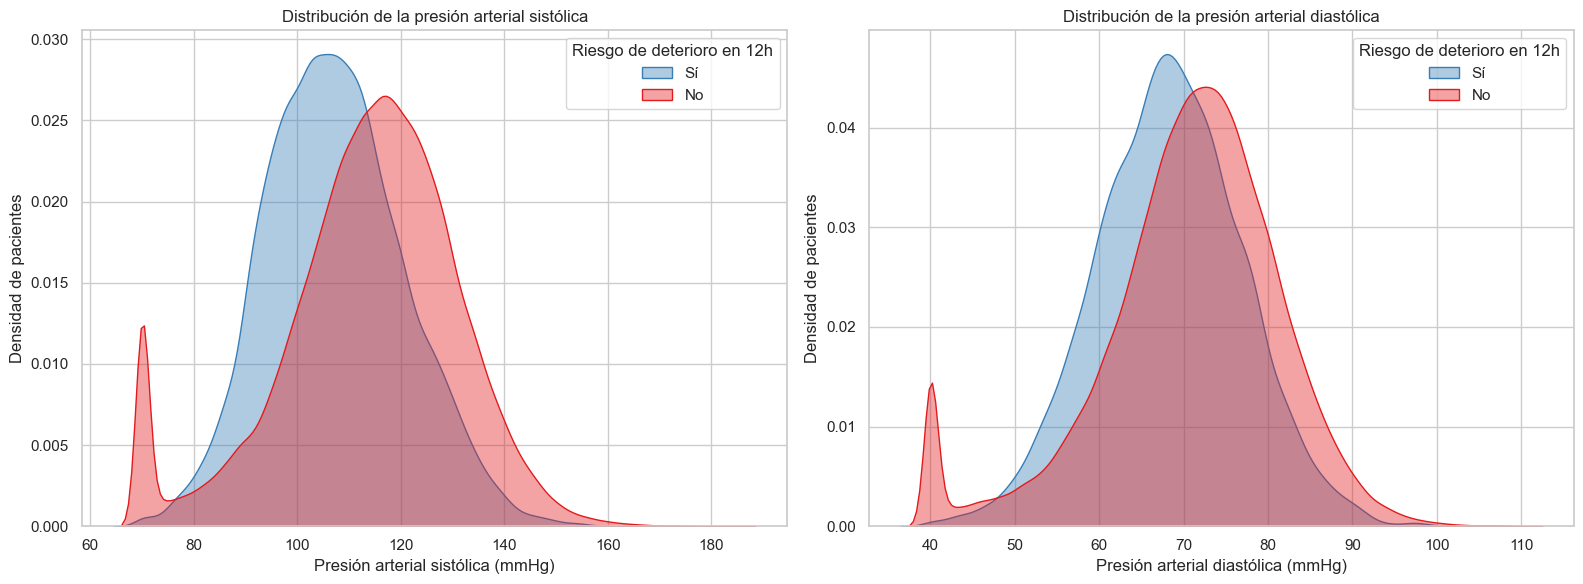

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(
    data=df_ml, x="systolic_bp", hue="deterioration_next_12h", 
    fill=True, common_norm=False, palette="Set1", alpha=0.4, ax=axes[0]
)
axes[0].set_title("Distribución de la presión arterial sistólica")
axes[0].set_xlabel("Presión arterial sistólica (mmHg)")
axes[0].set_ylabel("Densidad de pacientes")
axes[0].legend(title="Riesgo de deterioro en 12h", labels=["Sí", "No"])

sns.kdeplot(
    data=df_ml, x="diastolic_bp", hue="deterioration_next_12h", 
    fill=True, common_norm=False, palette="Set1", alpha=0.4, ax=axes[1]
)
axes[1].set_title("Distribución de la presión arterial diastólica")
axes[1].set_xlabel("Presión arterial diastólica (mmHg)")
axes[1].set_ylabel("Densidad de pacientes")
axes[1].legend(title="Riesgo de deterioro en 12h", labels=["Sí", "No"])

plt.tight_layout()
plt.show()

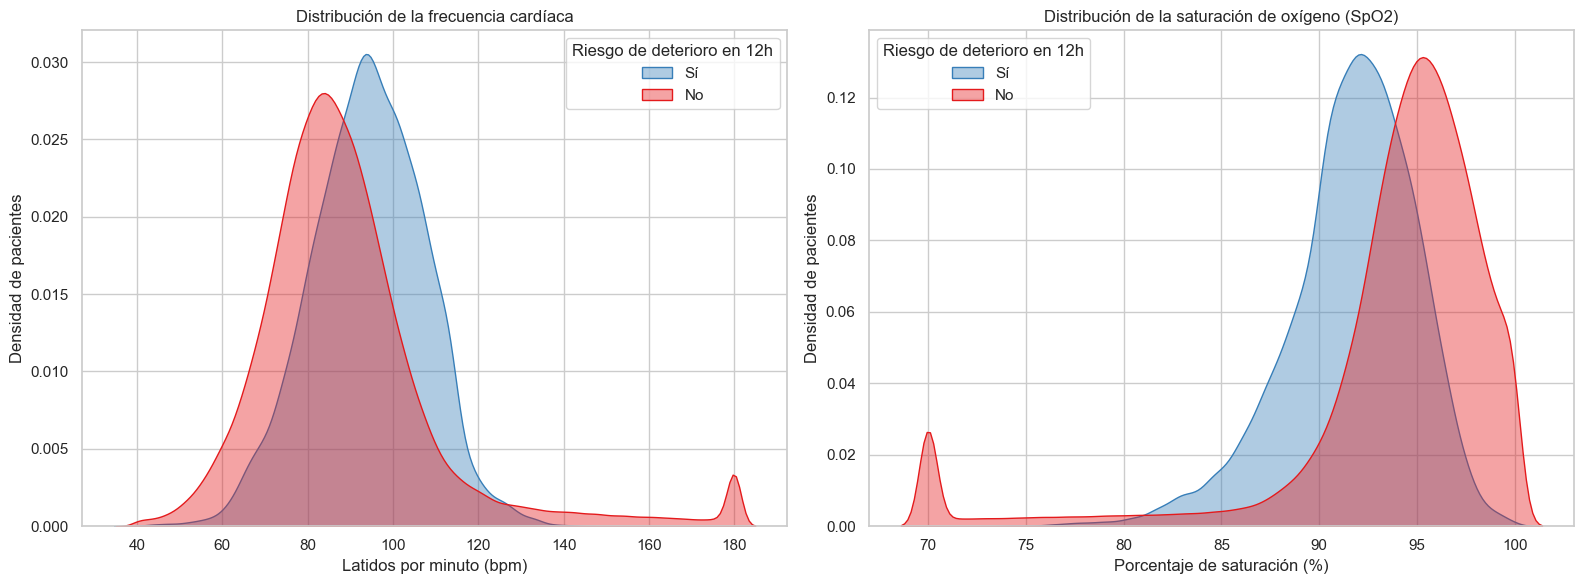

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(
    data=df_ml, x="heart_rate", hue="deterioration_next_12h", 
    fill=True, common_norm=False, palette="Set1", alpha=0.4, ax=axes[0]
)
axes[0].set_title("Distribución de la frecuencia cardíaca")
axes[0].set_xlabel("Latidos por minuto (bpm)")
axes[0].set_ylabel("Densidad de pacientes")
axes[0].legend(title="Riesgo de deterioro en 12h", labels=["Sí", "No"])

sns.kdeplot(
    data=df_ml, x="spo2_pct", hue="deterioration_next_12h", 
    fill=True, common_norm=False, palette="Set1", alpha=0.4, ax=axes[1]
)
axes[1].set_title("Distribución de la saturación de oxígeno (SpO2)")
axes[1].set_xlabel("Porcentaje de saturación (%)")
axes[1].set_ylabel("Densidad de pacientes")
axes[1].legend(title="Riesgo de deterioro en 12h", labels=["Sí", "No"])

plt.tight_layout()
plt.show()

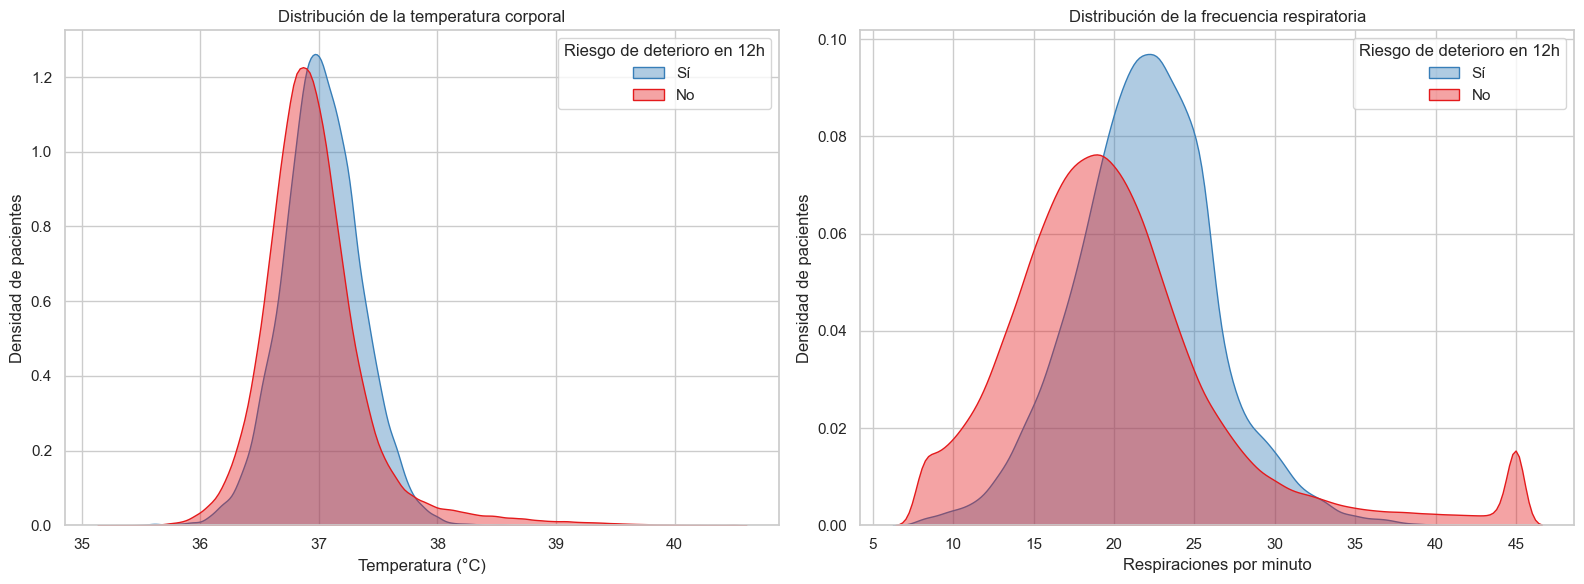

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(
    data=df_ml, x="temperature_c", hue="deterioration_next_12h", 
    fill=True, common_norm=False, palette="Set1", alpha=0.4, ax=axes[0]
)
axes[0].set_title("Distribución de la temperatura corporal")
axes[0].set_xlabel("Temperatura (°C)")
axes[0].set_ylabel("Densidad de pacientes")
axes[0].legend(title="Riesgo de deterioro en 12h", labels=["Sí", "No"])

sns.kdeplot(
    data=df_ml, x="respiratory_rate", hue="deterioration_next_12h", 
    fill=True, common_norm=False, palette="Set1", alpha=0.4, ax=axes[1]
)
axes[1].set_title("Distribución de la frecuencia respiratoria")
axes[1].set_xlabel("Respiraciones por minuto")
axes[1].set_ylabel("Densidad de pacientes")
axes[1].legend(title="Riesgo de deterioro en 12h", labels=["Sí", "No"])

plt.tight_layout()
plt.show()

### Diagramas de caja
#### Variables demográficas

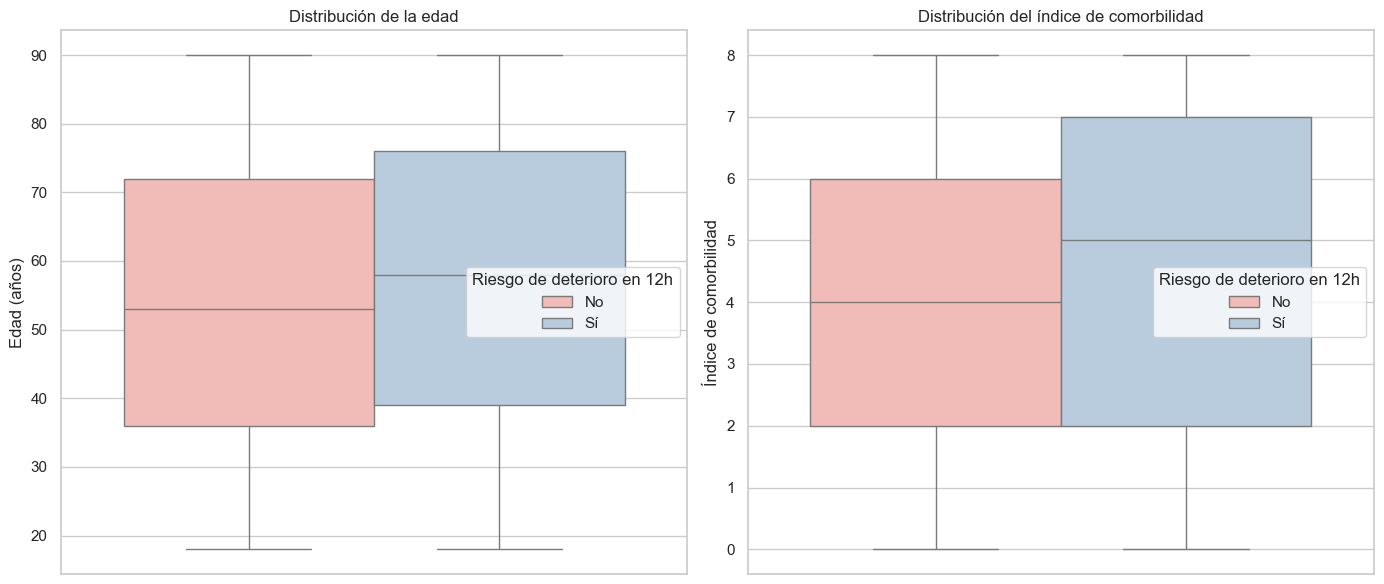

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df_ml, hue="deterioration_next_12h", y="age", 
    palette="Pastel1", ax=axes[0]
)
axes[0].set_title("Distribución de la edad")
axes[0].set_ylabel("Edad (años)")
axes[0].legend(title="Riesgo de deterioro en 12h", labels=["No", "Sí"])

sns.boxplot(
    data=df_ml, hue="deterioration_next_12h", y="comorbidity_index", 
    palette="Pastel1", ax=axes[1]
)
axes[1].set_title("Distribución del índice de comorbilidad")
axes[1].set_ylabel("Índice de comorbilidad")
axes[1].legend(title="Riesgo de deterioro en 12h", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

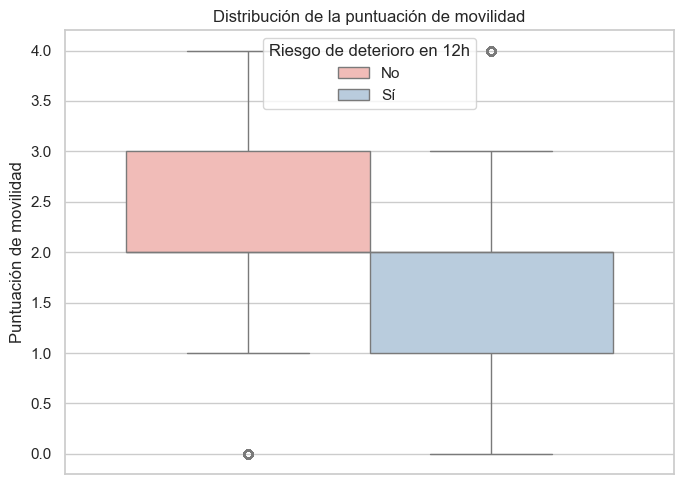

In [14]:
plt.figure(figsize=(7, 5))

graf = sns.boxplot(
    data=df_ml, hue="deterioration_next_12h", y="mobility_score", 
    palette="Pastel1"
)
graf.set_title("Distribución de la puntuación de movilidad")
graf.set_ylabel("Puntuación de movilidad")
graf.legend(title="Riesgo de deterioro en 12h", labels=["No", "Sí"])

plt.tight_layout()
plt.show()

#### Analíticas rápidas

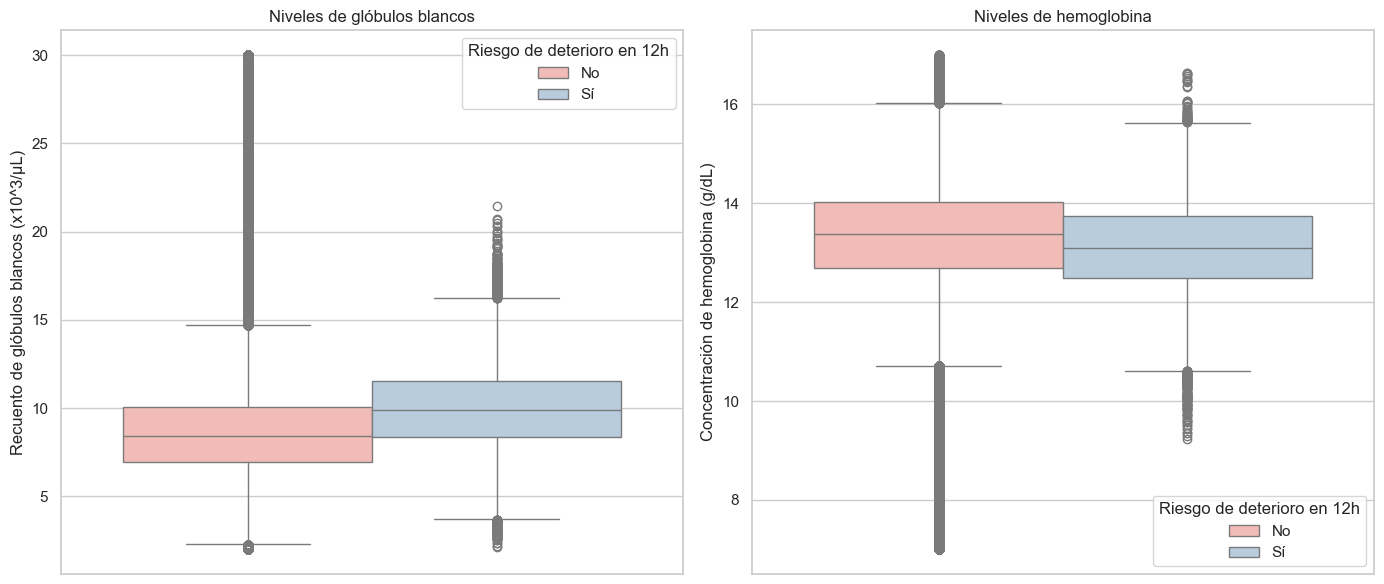

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df_ml, hue="deterioration_next_12h", y="wbc_count", 
    palette="Pastel1", ax=axes[0]
)
axes[0].set_title("Niveles de glóbulos blancos")
axes[0].set_ylabel("Recuento de glóbulos blancos (x10^3/μL)")
axes[0].legend(title="Riesgo de deterioro en 12h", labels=["No", "Sí"])
sns.boxplot(
    data=df_ml, hue="deterioration_next_12h", y="hemoglobin", 
    palette="Pastel1", ax=axes[1]
)
axes[1].set_title("Niveles de hemoglobina")
axes[1].set_ylabel("Concentración de hemoglobina (g/dL)")
axes[1].legend(title="Riesgo de deterioro en 12h", labels=["No", "Sí"])

plt.tight_layout()
plt.show()

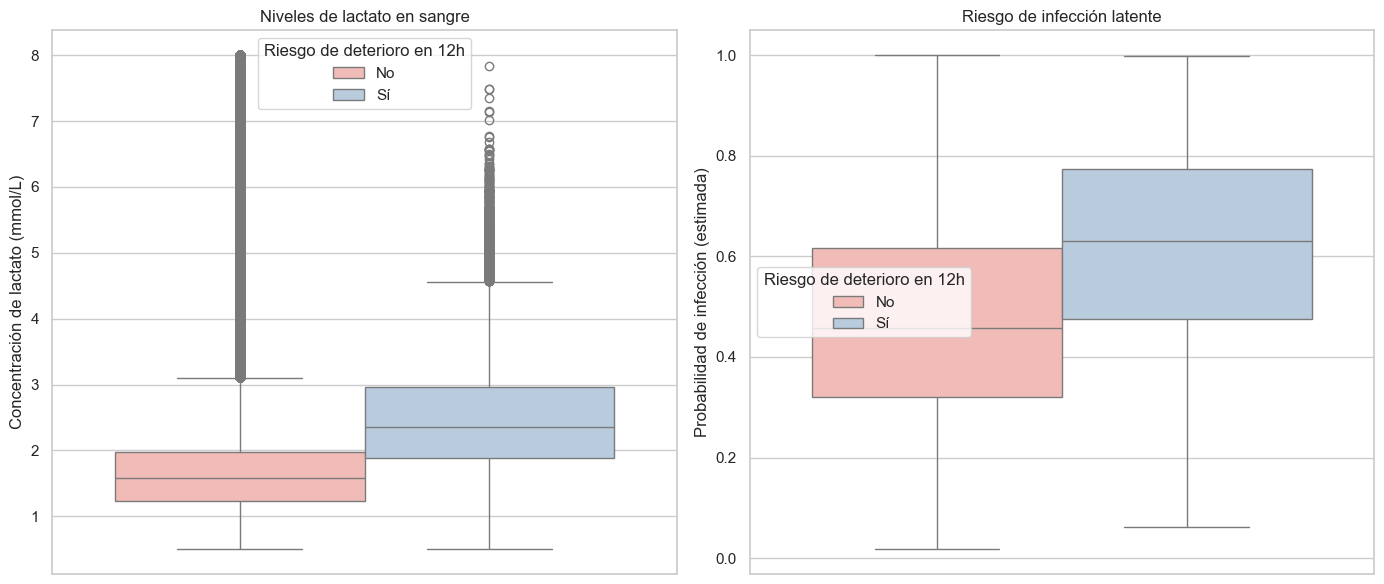

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df_ml, hue="deterioration_next_12h", y="lactate", 
    palette="Pastel1", ax=axes[0]
)
axes[0].set_title("Niveles de lactato en sangre")
axes[0].set_ylabel("Concentración de lactato (mmol/L)")
axes[0].legend(title="Riesgo de deterioro en 12h", labels=["No", "Sí"])

sns.boxplot(
    data=df_ml, hue="deterioration_next_12h", y="sepsis_risk_score", 
    palette="Pastel1", ax=axes[1]
)
axes[1].set_title("Riesgo de infección latente")
axes[1].set_ylabel("Probabilidad de infección (estimada)")
axes[1].legend(title="Riesgo de deterioro en 12h", labels=["No", "Sí"])

plt.tight_layout()
plt.show()

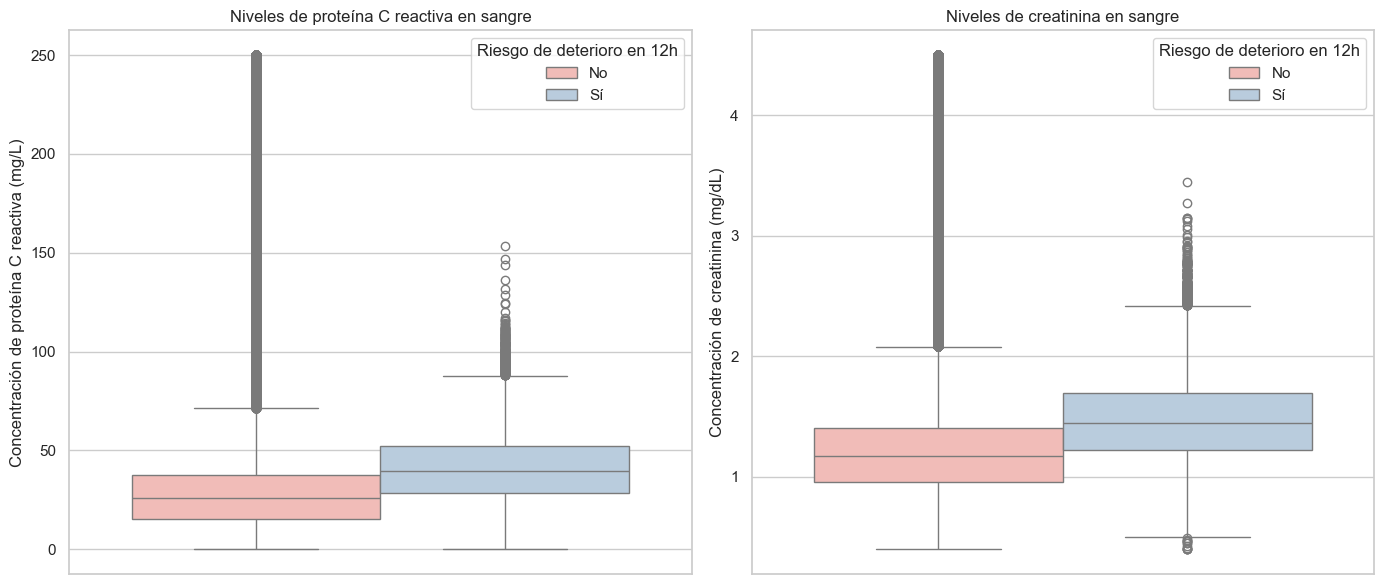

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=df_ml, hue="deterioration_next_12h", y="crp_level", 
    palette="Pastel1", ax=axes[0]
)
axes[0].set_title("Niveles de proteína C reactiva en sangre")
axes[0].set_ylabel("Concentración de proteína C reactiva (mg/L)")
axes[0].legend(title="Riesgo de deterioro en 12h", labels=["No", "Sí"])

sns.boxplot(
    data=df_ml, hue="deterioration_next_12h", y="creatinine", 
    palette="Pastel1", ax=axes[1]
)
axes[1].set_title("Niveles de creatinina en sangre")
axes[1].set_ylabel("Concentración de creatinina (mg/dL)")
axes[1].legend(title="Riesgo de deterioro en 12h", labels=["No", "Sí"])

plt.tight_layout()
plt.show()

## Codificación de datos no númericos

In [18]:
columnas_no_numericas = ['admission_type', 'gender', 'oxygen_device']

datos_numerizados = pd.get_dummies(df_ml, columns=columnas_no_numericas, dtype=int)

print("Columnas generadas:")
print(datos_numerizados.columns.tolist()[19:])

Columnas generadas:
['admission_type_ED', 'admission_type_Elective', 'admission_type_Transfer', 'gender_F', 'gender_M', 'oxygen_device_hfnc', 'oxygen_device_mask', 'oxygen_device_nasal', 'oxygen_device_niv', 'oxygen_device_none']


## Balanceo de la variable objetivo

In [19]:
y = datos_numerizados['deterioration_next_12h']
x = datos_numerizados.drop(columns=['deterioration_next_12h'])

### División para K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
n_particiones = 5
skf = StratifiedKFold(n_splits=n_particiones, shuffle=True, random_state=33)

### Ajuste de pesos

In [21]:
peso_desbalanceo = distribucion_deterioro[0]/distribucion_deterioro[1]
print(f"Peso de desbalanceo: {peso_desbalanceo:.5f}")

Peso de desbalanceo: 17.49865


## Normalización de datos

In [22]:
print(x.columns)

Index(['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct',
       'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_flow',
       'mobility_score', 'nurse_alert', 'wbc_count', 'lactate', 'creatinine',
       'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age',
       'comorbidity_index', 'admission_type_ED', 'admission_type_Elective',
       'admission_type_Transfer', 'gender_F', 'gender_M', 'oxygen_device_hfnc',
       'oxygen_device_mask', 'oxygen_device_nasal', 'oxygen_device_niv',
       'oxygen_device_none'],
      dtype='str')


In [ ]:
from sklearn.preprocessing import StandardScaler

variables_numericas_no_binarias = [
    'hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct',
    'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_flow',
    'mobility_score', 'wbc_count', 'lactate', 'creatinine',
    'crp_level', 'hemoglobin', 'age', 'comorbidity_index'
]

scaler = StandardScaler()

## Generación del csv preparado

In [24]:
datos_numerizados.to_csv("../../data/hospital_deterioration_ml_ready_prepared.csv", index=False)

## Generación del JSON de configuración de la API:

In [ ]:
import json

config_api = {
    "variables_a_escalar": variables_numericas_no_binarias,
    "peso_desbalanceo": float(peso_desbalanceo)
}

with open("../config/preprocesamiento_api.json", "w") as f:
    json.dump(config_api, f, indent=4)

: 